<table style="background-color: transparent;">
    <tr style="background-color: transparent;">
        <td width="400px"><font size="15px" color="#76a596">Quinta<br>Escuela<br>de Verano</font></td>
        <td><img width="700" style="display:block; margin-left: auto; margin-right: auto;" src="https://images.claudiazm.xyz/ecc26/header.png"></td>
    </tr>
</table>

<p style="text-align:right; font-weight:bold;">Autora: Claudia Zendejas-Morales</p>

# <center> Optimización Cuántica: Modelos y Algoritmos

## Contenido

1. [De la búsqueda a la optimización](#1)
2. [Dos formas de escribir un problema: QUBO e Ising](#2)
    1. [QUBO](#2.1)
    2. [Modelo de Ising](#2.2)
3. [Annealing cuántico](#3)
4. [QAOA](#4)
    1. [Idea del algoritmo](#4.1)
    2. [Ejemplo: asignación de canales como Max-Cut](#4.2)
5. [Problema de la mochila con Qiskit Optimization](#5)
    1. [Formulación](#5.1)
    2. [Construcción con una clase de aplicación](#5.2)
    3. [Resolución y lectura del resultado](#5.3)
    4. [De una mochila a otros problemas](#5.4)
6. [VQE para el estudio de moléculas](#6)
7. [¿Qué enfoque conviene usar?](#7)
8. [Referencias](#8)

<a id="1"></a>
# 1. De la búsqueda a la optimización

Grover muestra cómo amplificar las soluciones reconocidas por un oráculo. Muchos problemas reales, sin embargo, no preguntan únicamente si una solución es válida: buscan la **mejor** ruta, asignación o distribución de recursos según una función de costo.

Una estrategia consiste en convertir la optimización en varias búsquedas: dado un umbral, preguntamos si existe una solución mejor que ese valor. Otra estrategia codifica directamente la calidad de cada solución en una función matemática o en un Hamiltoniano. En este notebook estudiaremos tres conceptos de esta segunda familia:

* **QUBO**, una formulación matemática de optimización binaria
* **Ising**, una formulación equivalente inspirada en sistemas de espines
* **QAOA y annealing cuántico**, dos enfoques distintos que utilizan esa estructura para buscar soluciones de buena calidad

Los ejemplos son pequeños y se ejecutarán en simuladores ideales. Su propósito es mostrar el flujo completo desde un problema hasta un circuito, no demostrar ningún tipo de ventaja cuántica práctica.

<div style="color:#31708f; background-color:#d9edf7; border:1px solid #bce8f1; border-radius:4px; padding:15px; margin-bottom:20px;">
<strong>Una distinción importante</strong><br><br>
QUBO e Ising son formas de representar un problema. QAOA es un algoritmo de circuitos variacionales. El annealing cuántico es otro modelo de cómputo y utiliza una evolución física diferente. No son cuatro algoritmos intercambiables.
</div>

<a id="2"></a>
# 2. Dos formas de escribir un problema: QUBO e Ising

<a id="2.1"></a>
## 2.1. QUBO

Un problema **QUBO** (*Quadratic Unconstrained Binary Optimization*) busca una cadena binaria $x=(x_0,\ldots,x_{n-1})$, con $x_i\in\{0,1\}$, que minimice una función cuadrática:

$$
f(x)=\sum_i q_i x_i+\sum_{i<j}q_{ij}x_i x_j
$$

Los términos lineales asignan un costo o beneficio a cada decisión. Los términos cuadráticos representan interacciones entre pares de decisiones. Por ejemplo, pueden premiar que dos tareas se asignen juntas o penalizar que dos antenas utilicen el mismo canal.

QUBO no nació de un único artículo con ese nombre. Sus bases se encuentran en la optimización de funciones pseudobooleanas. El trabajo de [Boros y Hammer (2002)](https://doi.org/10.1016/S0166-218X(01)00341-9) presenta una revisión fundamental de esa teoría, mientras que [Kochenberger et al. (2014)](https://doi.org/10.1007/s10878-014-9734-0) consolidaron la formulación QUBO moderna y mostraron cómo representar numerosos problemas combinatorios. Como ejemplo de uso, [Date et al. (2021)](https://doi.org/10.1038/s41598-021-89461-4) construyeron formulaciones QUBO para entrenar modelos de aprendizaje automático y las estudiaron con solucionadores clásicos y cuánticos.

La palabra *unconstrained* no significa que el problema original carezca de restricciones. Condiciones como una capacidad máxima pueden incorporarse mediante variables auxiliares y penalizaciones que encarecen las soluciones inválidas. Elegir una penalización suficiente, pero no desproporcionada, es parte del modelado.

<div align="center">
<img alt="Grafo que ilustra variables binarias y sus interacciones por pares en un problema QUBO" width="430" style="display:block; margin-left:auto; margin-right:auto;" src="https://upload.wikimedia.org/wikipedia/commons/1/1f/GraphforQAOA.png">
</div>
<p align="center"><small>Un QUBO puede visualizarse como un grafo: cada vértice representa una variable binaria y cada arista una interacción cuadrática. <a href="https://commons.wikimedia.org/wiki/File:GraphforQAOA.png">Imagen obtenida de Wikimedia Commons</a>.</small></p>

<a id="2.2"></a>
## 2.2. Modelo de Ising

El modelo de Ising utiliza variables $z_i\in\{-1,+1\}$ y una función de energía:

$$
H(z)=\sum_i h_i z_i+\sum_{i<j}J_{ij}z_i z_j
$$

El modelo fue introducido en física estadística por [Ernst Ising en 1925](https://doi.org/10.1007/BF02980577) para estudiar el ferromagnetismo mediante espines con dos orientaciones e interacciones entre vecinos. Mucho después se reconoció también como un lenguaje para la optimización. [Barahona (1982)](https://doi.org/10.1088/0305-4470/15/10/028) analizó la complejidad computacional de modelos de espines de Ising, y [Lucas (2014)](https://doi.org/10.3389/fphy.2014.00005) mostró formulaciones de numerosos problemas NP en Hamiltonianos de Ising.

Mediante el cambio de variable

$$
x_i=\frac{1-z_i}{2}
$$

un QUBO puede transformarse en un modelo de Ising y viceversa. En un circuito, $z_i$ se asocia con los valores propios del operador de Pauli $Z_i$. Por ello la función de costo se convierte en un Hamiltoniano formado por términos $Z_i$ y $Z_iZ_j$.

Buscar la mejor solución clásica equivale entonces a buscar una cadena que minimice la energía del Hamiltoniano. Esta conexión permite utilizar técnicas desarrolladas tanto para circuitos cuánticos como para annealing.

<div align="center">
<img alt="Modelo de Ising bidimensional con espines en una retícula" width="430" style="display:block; margin-left:auto; margin-right:auto;" src="https://upload.wikimedia.org/wikipedia/commons/f/fe/2D_ising_model_on_lattice.svg">
</div>
<p align="center"><small>Representación de un modelo de Ising bidimensional. Cada flecha simboliza una variable de espín y las líneas muestran interacciones locales. <a href="https://commons.wikimedia.org/wiki/File:2D_ising_model_on_lattice.svg">Imagen obtenida de Wikimedia Commons</a>.</small></p>

<details>
<summary><strong>Ejemplo mínimo de la transformación</strong></summary>

Si el costo contiene $x_0x_1$, sustituimos $x_i=(1-z_i)/2$:

$$
x_0x_1=\frac{(1-z_0)(1-z_1)}{4}
=\frac{1-z_0-z_1+z_0z_1}{4}
$$

Un término cuadrático binario produce una constante, dos términos lineales de Ising y una interacción $z_0z_1$. La constante desplaza todas las energías por igual, por lo que no cambia cuál cadena es óptima.
</details>

<a id="3"></a>
# 3. Annealing cuántico

El **annealing cuántico** comienza con un Hamiltoniano cuyo estado de mínima energía es fácil de preparar. Después modifica gradualmente el sistema hasta obtener un Hamiltoniano que representa el problema. Si la evolución es suficientemente lenta y se cumplen las condiciones apropiadas, el sistema puede permanecer cerca de un estado de baja energía del problema final.

En términos intuitivos, se construye un paisaje de energía en el que las soluciones se encuentran en valles. Las fluctuaciones cuánticas ayudan a explorar el paisaje y el proceso intenta terminar en un valle profundo. En dispositivos reales se repite el experimento muchas veces y se obtiene una distribución de soluciones, no una garantía de encontrar siempre el óptimo.

El antecedente clásico es el recocido simulado de [Kirkpatrick, Gelatt y Vecchi (1983)](https://doi.org/10.1126/science.220.4598.671). [Kadowaki y Nishimori (1998)](https://doi.org/10.1103/PhysRevE.58.5355) formularon el annealing cuántico mediante un campo transversal en el modelo de Ising. Posteriormente se ha estudiado en experimentos como la optimización de vidrios de espín completamente conectados de [Venturelli et al. (2015)](https://doi.org/10.1103/PhysRevX.5.031040) y en aplicaciones como la optimización del flujo vehicular de [Neukart et al. (2017)](https://doi.org/10.3389/fict.2017.00029).

El annealing cuántico se ha aplicado experimentalmente a formulaciones de rutas, calendarización, asignación y otros problemas QUBO. Esto no implica por sí mismo una ventaja sobre los mejores métodos clásicos: influyen la conectividad del dispositivo, la representación del problema, el ruido, los parámetros de la evolución y el costo de insertar el problema en el hardware.

<div align="center">
<img alt="Analogía de un paisaje de energía para explicar annealing cuántico" width="600" style="display:block; margin-left:auto; margin-right:auto;" src="https://upload.wikimedia.org/wikipedia/commons/4/47/Quantum_Annealing_Analogy.svg">
</div>
<p align="center"><small>Analogía de un paisaje de energía: el proceso intenta llevar el sistema hacia estados de energía baja. Es una representación intuitiva, no una trayectoria literal del sistema. <a href="https://commons.wikimedia.org/wiki/File:Quantum_Annealing_Analogy.svg">Imagen obtenida Wikimedia Commons</a>.</small></p>

<div style="color:#3c763d; background-color:#dff0d8; border:1px solid #d6e9c6; border-radius:4px; padding:15px; margin-bottom:20px;">
<strong>Annealing no es QAOA</strong><br><br>
El annealing cuántico implementa una evolución física continua o discretizada en hardware especializado. QAOA construye un circuito de compuertas con capas parametrizadas y utiliza un optimizador clásico. Ambos pueden partir de una función Ising, pero sus mecanismos y plataformas son diferentes.
</div>

<a id="4"></a>
# 4. QAOA

El **Quantum Approximate Optimization Algorithm** (QAOA) es un algoritmo híbrido variacional. La computadora cuántica prepara y mide estados parametrizados, mientras que una computadora clásica ajusta los parámetros para mejorar el valor promedio de la función objetivo.

QAOA fue propuesto por [Farhi, Goldstone y Gutmann (2014)](https://arxiv.org/abs/1411.4028), inicialmente con Max-Cut como ejemplo central. [Hadfield et al. (2019)](https://doi.org/10.3390/a12020034) extendieron la idea al *Quantum Alternating Operator Ansatz*, que permite diseñar mezcladores adaptados a las restricciones del problema. Como demostración experimental, [Harrigan et al. (2021)](https://doi.org/10.1038/s41567-020-01105-y) ejecutaron QAOA para grafos no planos en un procesador superconductivo de Google.

QAOA busca concentrar probabilidad en soluciones de buena calidad. Para una profundidad finita $p$ no garantiza encontrar el óptimo, y aumentar $p$ produce circuitos más expresivos pero también más largos y difíciles de ejecutar en hardware ruidoso.

<div align="center">
<img alt="Circuito QAOA con una preparación inicial y capas alternadas de costo y mezcla" width="780" style="display:block; margin-left:auto; margin-right:auto;" src="https://qiskit.qotlabs.org/docs/images/tutorials/quantum-approximate-optimization-algorithm/circuit-diagram.svg">
</div>
<p align="center"><small>En QAOA se prepara un estado inicial y se aplican $p$ capas alternadas. Cada capa contiene un operador de costo $U(C,\gamma)$ y un mezclador $U(B,\beta)$. Las mediciones permiten estimar el costo y un optimizador clásico actualiza los parámetros. Imagen obtenida del <a href="https://qiskit.qotlabs.org/docs/tutorials/quantum-approximate-optimization-algorithm">tutorial de Qiskit sobre QAOA</a>.</small></p>

<a id="4.1"></a>
## 4.1. Idea del algoritmo

Una ejecución de QAOA sigue este ciclo:

1. Se prepara una superposición de las cadenas candidatas.
2. El **operador de costo** añade fases que dependen de la calidad de cada cadena.
3. El **operador mezclador** redistribuye amplitudes entre las cadenas.
4. Se repiten las capas de costo y mezcla $p$ veces.
5. Se mide el circuito y se estima el valor esperado del costo.
6. Un optimizador clásico propone nuevos ángulos $\gamma$ y $\beta$.

El operador de costo no entrega por sí solo la respuesta. Codifica la función objetivo en fases; la interferencia producida por la secuencia completa es la que modifica las probabilidades de medición.

<a id="4.2"></a>
## 4.2. Ejemplo: asignación de canales como Max-Cut

Supongamos que cuatro antenas deben usar uno de dos canales. Una arista conecta dos antenas que podrían interferir entre sí, y su peso indica la importancia de separarlas. Representamos los canales con $0$ y $1$. Queremos que la mayor suma posible de pesos conecte antenas asignadas a canales diferentes.

Esta abstracción produce un problema Max-Cut ponderado. Es un modelo deliberadamente pequeño: una planificación real incluiría más canales, cobertura, demanda, potencias y otras restricciones.

<div align="center"><img width="900px" style="display:block; margin-left: auto; margin-right: auto;" src="https://images.claudiazm.xyz/ecc26/WeightedMaxCutAntennas.gif"></div>

No utilizaremos una implementación prefabricada de QAOA. Escribiremos sus componentes para observar la relación entre el problema y el circuito.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# (antena i, antena j, importancia de separarlas)
aristas = [
    (0, 1, 2.0),
    (0, 2, 1.0),
    (1, 2, 1.0),
    (1, 3, 1.0),
    (2, 3, 2.0),
]
n_qubits = 4

Primero escribimos una función clásica que evalúa una asignación. Esta misma regla define el problema y nos permitirá interpretar las mediciones.

In [2]:
def valor_corte(bits, aristas):
    """Suma los pesos de las aristas cuyos extremos usan canales distintos."""
    return sum(peso for i, j, peso in aristas if bits[i] != bits[j])


def bits_desde_indice(indice, n):
    # El bit i corresponde al qubit i de Qiskit.
    return [(indice >> i) & 1 for i in range(n)]


for indice in range(2**n_qubits):
    bits = bits_desde_indice(indice, n_qubits)
    print("".join(map(str, bits)), valor_corte(bits, aristas))

0000 0
1000 3.0
0100 4.0
1100 3.0
0010 4.0
1010 5.0
0110 6.0
1110 3.0
0001 3.0
1001 6.0
0101 5.0
1101 4.0
0011 3.0
1011 4.0
0111 3.0
1111 0


Ahora construimos una capa de QAOA. Para Max-Cut, cada arista aporta

$$
C_{ij}=w_{ij}\frac{I-Z_iZ_j}{2}
$$

Este operador vale $w_{ij}$ cuando los bits son diferentes y $0$ cuando son iguales. Ignorando una fase global, su evolución se implementa con dos CNOT y una rotación $R_Z$. El mezclador utiliza rotaciones $R_X$ sobre todos los qubits.

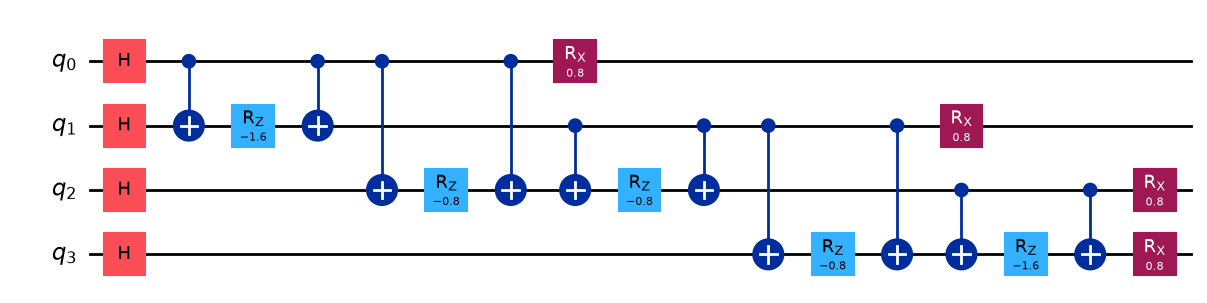

In [3]:
def circuito_qaoa(gamma, beta, aristas, n):
    circuito = QuantumCircuit(n)
    circuito.h(range(n))

    # Operador de costo: exp(-i gamma C).
    for i, j, peso in aristas:
        circuito.cx(i, j)
        circuito.rz(-gamma * peso, j)
        circuito.cx(i, j)

    # Operador mezclador: exp(-i beta sum_i X_i).
    circuito.rx(2 * beta, range(n))
    return circuito


circuito_qaoa(gamma=0.8, beta=0.4, aristas=aristas, n=n_qubits).draw("mpl")

En hardware, el valor esperado se estimaría con un número finito de *shots*. Aquí usamos `Statevector` para separar la idea del algoritmo de los errores de muestreo y del ruido.

In [4]:
def distribucion_qaoa(parametros):
    gamma, beta = parametros
    circuito = circuito_qaoa(gamma, beta, aristas, n_qubits)
    estado = Statevector.from_instruction(circuito)
    return estado.probabilities()


def costo_clasico(parametros):
    probabilidades = distribucion_qaoa(parametros)
    valor_esperado = sum(
        prob * valor_corte(bits_desde_indice(i, n_qubits), aristas)
        for i, prob in enumerate(probabilidades)
    )
    return -valor_esperado  # scipy minimiza; nosotros queremos maximizar el corte


resultado = minimize(
    costo_clasico,
    x0=np.array([0.8, 0.4]),
    method="COBYLA",
    options={"maxiter": 100},
)

print("Parámetros encontrados:", resultado.x)
print("Valor esperado del corte:", -resultado.fun)

Parámetros encontrados: [0.46894762 0.33792436]
Valor esperado del corte: 4.889387247532385


Finalmente examinamos las cadenas más probables. Una asignación y su complemento describen el mismo corte, pues intercambiar los nombres de los canales no cambia qué antenas están separadas.

Asignaciones más probables:
1001: probabilidad=0.204, valor=6.0
0110: probabilidad=0.204, valor=6.0
1010: probabilidad=0.154, valor=5.0
0101: probabilidad=0.154, valor=5.0
0011: probabilidad=0.047, valor=3.0
1100: probabilidad=0.047, valor=3.0


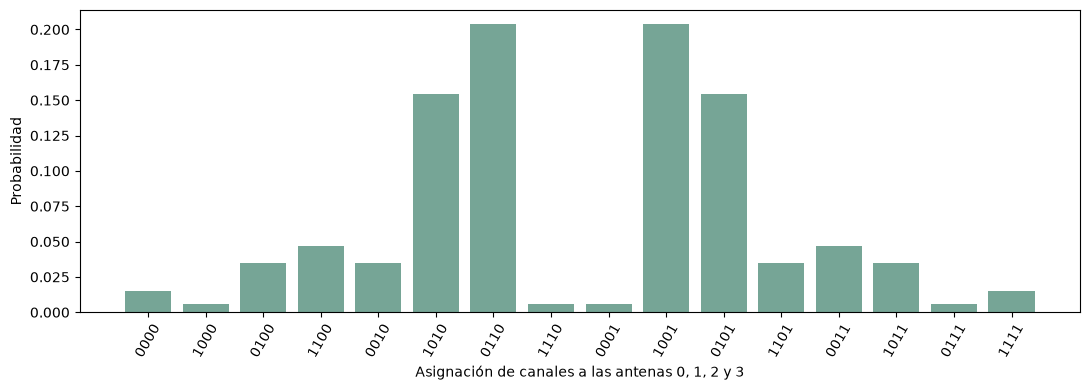

In [5]:
probabilidades = distribucion_qaoa(resultado.x)
orden = np.argsort(probabilidades)[::-1]

print("Asignaciones más probables:")
for indice in orden[:6]:
    bits = bits_desde_indice(indice, n_qubits)
    etiqueta = "".join(map(str, bits))
    print(
        f"{etiqueta}: probabilidad={probabilidades[indice]:.3f}, "
        f"valor={valor_corte(bits, aristas):.1f}"
    )

etiquetas = ["".join(map(str, bits_desde_indice(i, n_qubits))) for i in range(2**n_qubits)]
plt.figure(figsize=(11, 4))
plt.bar(etiquetas, probabilidades, color="#76a596")
plt.xlabel("Asignación de canales a las antenas 0, 1, 2 y 3")
plt.ylabel("Probabilidad")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

<div style="color:#3c763d; background-color:#dff0d8; border:1px solid #d6e9c6; border-radius:4px; padding:15px; margin-bottom:20px;">
<strong>Qué debemos observar</strong><br><br>
El circuito no almacena una lista de respuestas. La función de costo asigna fases según las aristas cortadas y el mezclador convierte parte de esa información de fase en diferencias de probabilidad. El optimizador clásico busca ángulos que concentren más probabilidad en cortes de valor alto. Al medir una sola vez todavía podríamos obtener una solución inferior, por lo que se realizan múltiples ejecuciones y se conserva la mejor cadena observada.
</div>

<details>
<summary><strong>¿Por qué este ejemplo no demuestra ventaja cuántica?</strong></summary>

Con cuatro bits podemos enumerar las 16 asignaciones en una computadora clásica. Además, calculamos probabilidades exactas con un simulador de vector de estado, cuyo costo crece exponencialmente.

En instancias grandes también deben considerarse la profundidad del circuito, el número de mediciones, el trabajo del optimizador clásico y la calidad de los algoritmos clásicos especializados. El ejemplo demuestra el mecanismo de QAOA y cómo modelar una aplicación, no superioridad práctica.
</details>

<a id="5"></a>
# 5. Problema de la mochila con Qiskit Optimization

El **problema de la mochila** (*Knapsack Problem*) consiste en elegir objetos con diferentes pesos y valores sin superar la capacidad disponible. Imaginemos que una persona prepara una mochila para escalar una montaña. No puede llevar todo: una cuerda ocupa y pesa más que una brújula, pero ambos objetos pueden ser muy útiles; un libro puede ofrecer entretenimiento durante el descanso, aunque normalmente tendrá menor prioridad para la seguridad de la expedición.

Para cada objeto definimos una variable binaria:

$$
x_i=
\begin{cases}
1, & \text{si elegimos el objeto }i\\
0, & \text{si no lo elegimos}
\end{cases}
$$

Queremos maximizar

$$
\sum_i v_i x_i
$$

sujeto a

$$
\sum_i w_i x_i\leq W
$$

El peso representa cuánto consume cada objeto de la capacidad disponible y el valor expresa su utilidad relativa para la excursión. En una situación real, elementos esenciales de seguridad no deberían tratarse como opcionales y habría que incluir más restricciones. Este ejemplo es únicamente una abstracción educativa.

<a id="5.1"></a>
## 5.1. Formulación

Usaremos cuatro objetos y una mochila con capacidad 6. Los pesos y valores son unidades simplificadas, no kilogramos ni una recomendación para una expedición real:

| Objeto | Índice | Valor | Peso |
|---|:--:|:--:|:--:|
| Libro de bolsillo | 0 | 2 | 2 |
| Brújula | 1 | 7 | 1 |
| Botiquín | 2 | 9 | 3 |
| Cuerda | 3 | 13 | 5 |

Aunque podríamos escribir manualmente la función y sus restricciones, `qiskit-optimization` proporciona clases que realizan esta traducción y conservan la información necesaria para interpretar el resultado.

Para esta sección se requiere los paquetes Qiskit Optimization y Qiskit Algorithms:

```bash
pip install qiskit-optimization qiskit-algorithms
```

`qiskit-optimization` modela y convierte el problema. `qiskit-algorithms` proporciona solucionadores de valores propios, optimizadores clásicos y una implementación reutilizable de QAOA.

<a id="5.2"></a>
## 5.2. Construcción con una clase de aplicación

In [6]:
from qiskit_optimization.applications import Knapsack

objetos = ["libro de bolsillo", "brújula", "botiquín", "cuerda"]
valores = [2, 7, 9, 13]
pesos = [2, 1, 3, 5]
capacidad = 6

mochila = Knapsack(valores, pesos, capacidad)
problema = mochila.to_quadratic_program()

print(problema.prettyprint())

Problem name: Knapsack

Maximize
  2*x_0 + 7*x_1 + 9*x_2 + 13*x_3

Subject to
  Linear constraints (1)
    2*x_0 + x_1 + 3*x_2 + 5*x_3 <= 6  'c0'

  Binary variables (4)
    x_0 x_1 x_2 x_3



El objeto `QuadraticProgram` contiene las variables, la función objetivo y la restricción de capacidad. También puede convertirse automáticamente a QUBO y después a un Hamiltoniano de Ising.

In [7]:
from qiskit_optimization.converters import QuadraticProgramToQubo

convertidor = QuadraticProgramToQubo()
qubo = convertidor.convert(problema)
operador_ising, desplazamiento = qubo.to_ising()

print(qubo.prettyprint())
print("\nHamiltoniano de Ising:")
print(operador_ising)
print("Desplazamiento de energía:", desplazamiento)

Problem name: Knapsack

Minimize
  32*c0@int_slack@0^2 + 128*c0@int_slack@0*c0@int_slack@1
  + 192*c0@int_slack@0*c0@int_slack@2 + 128*c0@int_slack@1^2
  + 384*c0@int_slack@1*c0@int_slack@2 + 288*c0@int_slack@2^2
  + 128*x_0*c0@int_slack@0 + 256*x_0*c0@int_slack@1 + 384*x_0*c0@int_slack@2
  + 128*x_0^2 + 128*x_0*x_1 + 384*x_0*x_2 + 640*x_0*x_3 + 64*x_1*c0@int_slack@0
  + 128*x_1*c0@int_slack@1 + 192*x_1*c0@int_slack@2 + 32*x_1^2 + 192*x_1*x_2
  + 320*x_1*x_3 + 192*x_2*c0@int_slack@0 + 384*x_2*c0@int_slack@1
  + 576*x_2*c0@int_slack@2 + 288*x_2^2 + 960*x_2*x_3 + 320*x_3*c0@int_slack@0
  + 640*x_3*c0@int_slack@1 + 960*x_3*c0@int_slack@2 + 800*x_3^2
  - 384*c0@int_slack@0 - 768*c0@int_slack@1 - 1152*c0@int_slack@2 - 770*x_0
  - 391*x_1 - 1161*x_2 - 1933*x_3 + 1152

Subject to
  No constraints

  Binary variables (7)
    x_0 x_1 x_2 x_3 c0@int_slack@0 c0@int_slack@1 c0@int_slack@2


Hamiltoniano de Ising:
SparsePauliOp(['IIIIIIZ', 'IIIIIZI', 'IIIIZII', 'IIIZIII', 'IIZIIII', 'IZIIIII', 'ZII

Las variables adicionales que pueden aparecer son bits de holgura usados para representar la desigualdad. La penalización hace que exceder la capacidad resulte desfavorable. Esta conversión es una de las ventajas prácticas de utilizar una biblioteca: evita construir manualmente todos esos términos, aunque seguimos siendo responsables de comprobar que el modelo represente el problema correcto.

<a id="5.3"></a>
## 5.3. Resolución y lectura del resultado

Antes de utilizar QAOA conviene obtener una referencia exacta para esta instancia diminuta. `NumPyMinimumEigensolver` diagonaliza el Hamiltoniano clásicamente. No es un algoritmo cuántico ni escala a problemas grandes, pero permite verificar la formulación.

In [8]:
from qiskit_algorithms import NumPyMinimumEigensolver
from qiskit_optimization.algorithms import MinimumEigenOptimizer

solucionador_exacto = MinimumEigenOptimizer(NumPyMinimumEigensolver())
resultado_exacto = solucionador_exacto.solve(problema)

print(resultado_exacto.prettyprint())
seleccion = mochila.interpret(resultado_exacto)
print("Objetos seleccionados:", [objetos[i] for i in seleccion])
print("Peso total:", sum(pesos[i] for i in seleccion))
print("Valor total:", sum(valores[i] for i in seleccion))

objective function value: 20.0
variable values: x_0=0.0, x_1=1.0, x_2=0.0, x_3=1.0
status: SUCCESS
Objetos seleccionados: ['brújula', 'cuerda']
Peso total: 6
Valor total: 20


En esta instancia, elegir la brújula y la cuerda utiliza toda la capacidad: pesa $1+5=6$ y aporta un valor $7+13=20$. La biblioteca devuelve la cadena binaria y `interpret` la traduce nuevamente a índices; nosotros utilizamos esos índices para recuperar los nombres de los objetos.

Podemos sustituir el solucionador exacto por QAOA. Ahora sí se ejecuta un circuito parametrizado, pero el resultado es aproximado y puede cambiar entre ejecuciones.

In [9]:
import warnings

from scipy.sparse import SparseEfficiencyWarning
from qiskit.primitives import StatevectorSampler
from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA

# Algunas operaciones internas producen advertencias de eficiencia de matrices dispersas
# No afectan el resultado y se ocultan solo dentro de este bloque
with warnings.catch_warnings():
    warnings.simplefilter("ignore", SparseEfficiencyWarning)

    qaoa = QAOA(
        sampler=StatevectorSampler(seed=123),
        optimizer=COBYLA(maxiter=100),
        reps=1,
    )
    solucionador_qaoa = MinimumEigenOptimizer(qaoa)
    resultado_qaoa = solucionador_qaoa.solve(problema)

print(resultado_qaoa.prettyprint())
seleccion_qaoa = mochila.interpret(resultado_qaoa)
print("Objetos seleccionados:", [objetos[i] for i in seleccion_qaoa])

objective function value: 20.0
variable values: x_0=0.0, x_1=1.0, x_2=0.0, x_3=1.0
status: SUCCESS
Objetos seleccionados: ['brújula', 'cuerda']


<div style="color:#31708f; background-color:#d9edf7; border:1px solid #bce8f1; border-radius:4px; padding:15px; margin-bottom:20px;">
<strong>Bibliotecas y abstracciones</strong><br><br>
La clase <code>Knapsack</code> facilita el modelado, pero no elimina la dificultad del problema. El solucionador exacto escala exponencialmente y QAOA no garantiza el óptimo con una profundidad pequeña. Las abstracciones ayudan a experimentar, comparar enfoques y reducir errores de implementación.
</div>

<a id="5.4"></a>
## 5.4. De una mochila a otros problemas

La importancia del problema de la mochila no está en preparar equipaje. Su estructura reaparece cuando debemos seleccionar opciones valiosas bajo recursos limitados. Cambian los nombres de los objetos, los valores y las capacidades, pero se conserva la pregunta esencial: **¿qué combinación produce mayor beneficio sin violar las restricciones?**

| Contexto | Objetos candidatos | Valor que se maximiza | Capacidades y restricciones |
|---|---|---|---|
| Carga de una aeronave | Paquetes, contenedores o pallets | Ingreso, prioridad o carga transportada | Peso, volumen, posición, balance y centro de gravedad |
| Selección de proyectos | Proyectos posibles | Beneficio o impacto esperado | Presupuesto, personal, tiempo y dependencias |
| Observaciones de un satélite | Solicitudes de imágenes o experimentos | Valor científico o comercial | Energía, almacenamiento, ventanas de tiempo y orientación |
| Asignación de cómputo | Tareas que esperan ejecución | Prioridad o utilidad completada | CPU, memoria, aceleradores y tiempo disponible |
| Portafolio simplificado | Activos o inversiones | Rendimiento esperado | Presupuesto y límites de exposición; el riesgo añade interacciones cuadráticas |
| Distribución logística | Pedidos que se asignan a vehículos | Ingreso o prioridad de entrega | Varias capacidades, vehículos y rutas |

En los casos con varios vehículos o compartimentos obtenemos un problema de **múltiples mochilas**. Cuando importan tanto el peso como el volumen, tenemos una **mochila multidimensional**. Si además interesa dónde se coloca cada objeto, el modelo se acerca a *bin packing* o carga con restricciones. La idea conocida sirve como punto de partida, pero no debemos eliminar detalles esenciales de la aplicación real.

### Carga de aeronaves: el caso de Airbus

El caso empresarial que coincide con la descripción de una compañía aeronáutica y una empresa cuántica está documentado para **Airbus, no Boeing**. [IonQ explica oficialmente su colaboración con Airbus](https://www.ionq.com/resources/learn-quantum-cargo-loading-optimization) para estudiar la distribución de carga en vuelos. Aquí un paquete ya no tiene solo peso y valor: también ocupa una posición, y la selección debe respetar el balance de la aeronave y otras condiciones operativas.

En 2025, [Kaushik et al.](https://arxiv.org/abs/2504.01567) presentaron una formulación de carga de aeronaves con una variante multiángulo de QAOA y reportaron experimentos de 12 a 28 qubits en procesadores IonQ Aria y Forte. Obtener el óptimo en esas instancias de investigación es evidencia de una implementación experimental, no de ventaja cuántica frente a toda la logística clásica ni de uso operativo en vuelos comerciales.

Por otra parte, [AWS documentó un estudio de Strangeworks](https://aws.amazon.com/blogs/quantum-computing/how-strangeworks-is-using-amazon-braket-to-explore-the-aircraft-cargo-loading-problem/) sobre el problema planteado por Airbus en su *Quantum Mobility Challenge*. El trabajo comparó variantes de QAOA y realizó pruebas con un procesador Rigetti disponible en Amazon Braket. Este es probablemente el recuerdo de una empresa aeronáutica trabajando con una startup.

### La misma estructura, diferentes herramientas

La formulación no obliga a usar QAOA. [Awasthi et al. (2023)](https://arxiv.org/abs/2301.05750) compararon QAOA, VQE, *warm-start QAOA* y annealing cuántico para problemas de múltiples mochilas. También existe una propuesta de [Nayak y Sahu (2022)](https://doi.org/10.1109/TQCEBT54229.2022.10041449) dedicada a optimizar carga aérea.

El procedimiento reutilizable es:

1. Identificar cuáles decisiones son binarias
2. Definir qué significa el valor en el nuevo contexto
3. Traducir todos los recursos limitados a restricciones
4. Añadir relaciones entre decisiones, como incompatibilidades o dependencias
5. Elegir un solucionador adecuado y compararlo con buenos métodos clásicos
6. Traducir la cadena binaria obtenida de vuelta a una decisión comprensible

Así, conocer una formulación como mochila proporciona una plantilla mental y matemática. La parte difícil sigue siendo modelar correctamente el nuevo problema y comprobar que la simplificación no descarte requisitos físicos, económicos o de seguridad.

<a id="6"></a>
# 6. VQE para el estudio de moléculas

Los algoritmos variacionales también se estudian fuera de la optimización combinatoria. El **Variational Quantum Eigensolver** (VQE) aproxima el estado de menor energía de un Hamiltoniano. En química cuántica, ese Hamiltoniano describe los electrones de una molécula bajo ciertas aproximaciones.

Un flujo típico es:

1. Especificar la molécula, su geometría y una base de orbitales
2. Calcular integrales electrónicas con software clásico
3. Transformar los operadores fermiónicos en operadores de qubits
4. Preparar un estado parametrizado y medir la energía
5. Ajustar los parámetros clásicamente hasta reducir esa energía

VQE fue propuesto pensando en circuitos relativamente cortos y se ha utilizado en demostraciones experimentales de moléculas pequeñas. Sin embargo, obtener precisión químicamente útil para sistemas relevantes exige controlar errores de modelado, preparación del estado, medición, ruido y optimización. No desarrollaremos aquí otro ejemplo porque requiere introducir estructura electrónica y paquetes como `qiskit-nature`.

Para estudiarlo con calma pueden consultarse el tutorial oficial de [solucionadores del estado base de Qiskit Nature](https://qiskit-community.github.io/qiskit-nature/tutorials/03_ground_state_solvers.html), el experimento original de [Peruzzo et al.](https://doi.org/10.1038/ncomms5213) y el análisis de [McClean et al.](https://doi.org/10.1088/1367-2630/18/2/023023).

<div align="center"><img width="500px" style="display:block; margin-left: auto; margin-right: auto;" src="https://media.springernature.com/m685/springer-static/image/art%3A10.1038%2Fncomms5213/MediaObjects/41467_2014_Article_BFncomms5213_Fig4_HTML.jpg"></div>

<p align="center"><small>Curva de disociación de $HeH^+$ obtenida en el experimento de VQE de <a href="https://doi.org/10.1038/ncomms5213">Peruzzo et al. (2014)</a>.</small></p>



### ¿Cómo se interpreta esta gráfica?

El eje horizontal representa la distancia $R$ entre los núcleos de helio e hidrógeno. El eje vertical muestra la energía electrónica del estado base. Para cada distancia se construye un Hamiltoniano diferente y VQE busca el estado de menor energía correspondiente.

* La **curva teórica** se obtuvo clásicamente mediante configuración-interacción completa (*full configuration interaction*, FCI) y funciona como referencia.
* Los **puntos experimentales** provienen del algoritmo variacional ejecutado en el procesador cuántico fotónico. La figura también permite observar el efecto de corregir el error sistemático medido por los autores.
* El **mínimo de la curva** indica la separación de equilibrio: si los núcleos están más cerca o más lejos, la energía aumenta y la configuración es menos estable.

Los autores estimaron una distancia de equilibrio de $92.3\pm0.1\ \text{pm}$ y una energía electrónica de $-2.865\pm0.008\ \text{MJ mol}^{-1}$. Además, reportaron que más del 96 % de los datos experimentales quedaron dentro del umbral de precisión química respecto a la curva teórica.

<div style="color:#31708f; background-color:#d9edf7; border:1px solid #bce8f1; border-radius:4px; padding:15px; margin-bottom:20px;">
<strong>¿Cuál es el valor “real”?</strong><br><br>
La curva FCI es numéricamente exacta para el Hamiltoniano molecular y la base finita usados en el experimento, por eso sirve para comprobar VQE en esta instancia pequeña. No es el valor físico absoluto de la molécula sin aproximaciones. La comparación importante es que el cálculo cuántico experimental reproduce de cerca esa referencia clásica y permite recuperar una propiedad con significado químico: la distancia de equilibrio.
</div>

<a id="7"></a>
# 7. ¿Qué enfoque conviene usar?

No existe un método cuántico universalmente mejor para todos los problemas de optimización.

| Concepto o enfoque | Papel principal | Pregunta útil |
|---|---|---|
| Grover | Buscar candidatos reconocidos por un oráculo | ¿Puedo comprobar eficientemente si una solución cumple un umbral? |
| QUBO/Ising | Representar decisiones e interacciones binarias | ¿Mi objetivo y mis restricciones caben en una función cuadrática? |
| Annealing cuántico | Explorar estados de baja energía mediante una evolución física | ¿Puedo insertar adecuadamente el modelo en el hardware disponible? |
| QAOA | Optimizar un circuito alternando costo y mezcla | ¿Qué profundidad, mezclador y estrategia clásica funcionan para esta instancia? |
| VQE | Aproximar energías y estados propios | ¿El problema puede expresarse como un Hamiltoniano cuyo estado base me interesa? |

Para evaluar una propuesta también debemos compararla con buenos algoritmos clásicos, contar el costo de preparar datos y medir, e incluir el trabajo del optimizador y el ruido del dispositivo.

<a id="8"></a>
# 8. Referencias

## Documentación y tutoriales

- Qiskit Optimization. [Clases de aplicaciones, incluido el problema de la mochila](https://qiskit-community.github.io/qiskit-optimization/tutorials/09_application_classes.html).
- Qiskit Optimization. [Conversión de problemas cuadráticos a QUBO](https://qiskit-community.github.io/qiskit-optimization/tutorials/02_converters_for_quadratic_programs.html).
- Qiskit Algorithms. [Tutorial de QAOA](https://qiskit-community.github.io/qiskit-algorithms/tutorials/05_qaoa.html).
- Qiskit Nature. [Solucionadores del estado base](https://qiskit-community.github.io/qiskit-nature/tutorials/03_ground_state_solvers.html).

## QUBO e Ising

- Ising, E. (1925). *Beitrag zur Theorie des Ferromagnetismus*. Zeitschrift für Physik, 31, 253-258. [https://doi.org/10.1007/BF02980577](https://doi.org/10.1007/BF02980577).
- Barahona, F. (1982). *On the Computational Complexity of Ising Spin Glass Models*. Journal of Physics A, 15, 3241-3253. [https://doi.org/10.1088/0305-4470/15/10/028](https://doi.org/10.1088/0305-4470/15/10/028).
- Boros, E. y Hammer, P. L. (2002). *Pseudo-Boolean Optimization*. Discrete Applied Mathematics, 123, 155-225. [https://doi.org/10.1016/S0166-218X(01)00341-9](https://doi.org/10.1016/S0166-218X(01)00341-9).
- Kochenberger, G. et al. (2014). *The Unconstrained Binary Quadratic Programming Problem: A Survey*. Journal of Combinatorial Optimization, 28, 58-81. [https://doi.org/10.1007/s10878-014-9734-0](https://doi.org/10.1007/s10878-014-9734-0).
- Lucas, A. (2014). *Ising Formulations of Many NP Problems*. Frontiers in Physics, 2, 5. [https://doi.org/10.3389/fphy.2014.00005](https://doi.org/10.3389/fphy.2014.00005).
- Date, P. et al. (2021). *QUBO Formulations for Training Machine Learning Models*. Scientific Reports, 11, 10029. [https://doi.org/10.1038/s41598-021-89461-4](https://doi.org/10.1038/s41598-021-89461-4).

## Annealing cuántico y QAOA

- Kirkpatrick, S., Gelatt, C. D. y Vecchi, M. P. (1983). *Optimization by Simulated Annealing*. Science, 220, 671-680. [https://doi.org/10.1126/science.220.4598.671](https://doi.org/10.1126/science.220.4598.671).
- Kadowaki, T. y Nishimori, H. (1998). *Quantum Annealing in the Transverse Ising Model*. Physical Review E, 58, 5355. [https://doi.org/10.1103/PhysRevE.58.5355](https://doi.org/10.1103/PhysRevE.58.5355).
- Venturelli, D. et al. (2015). *Quantum Optimization of Fully Connected Spin Glasses*. Physical Review X, 5, 031040. [https://doi.org/10.1103/PhysRevX.5.031040](https://doi.org/10.1103/PhysRevX.5.031040).
- Neukart, F. et al. (2017). *Traffic Flow Optimization Using a Quantum Annealer*. Frontiers in ICT, 4, 29. [https://doi.org/10.3389/fict.2017.00029](https://doi.org/10.3389/fict.2017.00029).
- Farhi, E., Goldstone, J. y Gutmann, S. (2014). *A Quantum Approximate Optimization Algorithm*. [https://arxiv.org/abs/1411.4028](https://arxiv.org/abs/1411.4028).
- Hadfield, S. et al. (2019). *From the Quantum Approximate Optimization Algorithm to a Quantum Alternating Operator Ansatz*. Algorithms, 12, 34. [https://doi.org/10.3390/a12020034](https://doi.org/10.3390/a12020034).
- Zhou, L., Wang, S.-T., Choi, S., Pichler, H. y Lukin, M. D. (2020). *Quantum Approximate Optimization Algorithm: Performance, Mechanism, and Implementation on Near-Term Devices*. Physical Review X, 10, 021067. [https://doi.org/10.1103/PhysRevX.10.021067](https://doi.org/10.1103/PhysRevX.10.021067).
- Harrigan, M. P. et al. (2021). *Quantum Approximate Optimization of Non-Planar Graph Problems on a Planar Superconducting Processor*. Nature Physics, 17, 332-336. [https://doi.org/10.1038/s41567-020-01105-y](https://doi.org/10.1038/s41567-020-01105-y).

## Mochila, carga y reutilización de modelos

- IonQ. [Cargo Loading Optimization: colaboración con Airbus](https://www.ionq.com/resources/learn-quantum-cargo-loading-optimization).
- AWS Quantum Technologies Blog. [How Strangeworks Is Using Amazon Braket to Explore the Aircraft Cargo Loading Problem](https://aws.amazon.com/blogs/quantum-computing/how-strangeworks-is-using-amazon-braket-to-explore-the-aircraft-cargo-loading-problem/).
- Awasthi, A. et al. (2023). *Quantum Computing Techniques for Multi-Knapsack Problems*. [https://arxiv.org/abs/2301.05750](https://arxiv.org/abs/2301.05750).
- Nayak, V. y Sahu, V. (2022). *Quantum Approach to Optimize Aircraft Cargo Loading*. International Conference on Trends in Quantum Computing and Emerging Business Technologies. [https://doi.org/10.1109/TQCEBT54229.2022.10041449](https://doi.org/10.1109/TQCEBT54229.2022.10041449).
- Kaushik, A., Kim, S. H., Aboumrad, W., Roetteler, M., Topi, A. y Ashworth, R. (2025). *Quantum Computing for Optimizing Aircraft Loading*. [https://arxiv.org/abs/2504.01567](https://arxiv.org/abs/2504.01567).

## Algoritmos variacionales y química

- Peruzzo, A. et al. (2014). *A Variational Eigenvalue Solver on a Photonic Quantum Processor*. Nature Communications, 5, 4213. [https://doi.org/10.1038/ncomms5213](https://doi.org/10.1038/ncomms5213).
- McClean, J. R., Romero, J., Babbush, R. y Aspuru-Guzik, A. (2016). *The Theory of Variational Hybrid Quantum-Classical Algorithms*. New Journal of Physics, 18, 023023. [https://doi.org/10.1088/1367-2630/18/2/023023](https://doi.org/10.1088/1367-2630/18/2/023023).